# Predicting Claim Denials with Machine Learning
### A small RCM (Revenue Cycle Management) project

This notebook is a hands-on companion to the idea of **predictive RCM**: instead of
finding out a claim was denied *after* the payer responds, we try to flag high-risk
claims *before* submission, so an AR/collections team can review them first.

**What this notebook does:**
1. Generates a realistic *synthetic* claims dataset (payer, CPT, provider, authorization, timing, etc.)
2. Engineers RCM-style risk features (payer denial rate, CPT denial rate, provider denial rate)
3. Trains three models — Logistic Regression, Random Forest, XGBoost — to predict `denied`
4. Evaluates them with the metrics that actually matter for denial prediction (recall, precision, ROC-AUC — not just accuracy)
5. Builds a **risk-sorted worklist**, the way a real AR team would triage claims
6. Adds a small **anomaly detection** demo (Isolation Forest) to catch a provider whose denial rate suddenly spikes

> ⚠️ The data below is **fully synthetic** — generated with `numpy`, not real patient or claims data.
> The point is to practice the ML workflow end-to-end on something that *feels* like real RCM data,
> the same way the article "How AI and ML Could Transform Healthcare Billing" describes it.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.figsize"] = (6, 4)

## 1. Generate a synthetic claims dataset

Each row is one claim, similar to the feature table in the article: payer, CPT code,
specialty, place of service, provider, modifier, authorization status, billed amount,
days-to-submission, and whether a similar claim was denied before.

The denial probability is built from a mix of these factors (payer risk, provider
"skill" i.e. how clean their claims tend to be, unclear authorization, late filing,
etc.) so the models below have real, learnable signal — the same way real payer and
provider denial patterns aren't random.

In [ ]:
rng = np.random.default_rng(RANDOM_STATE)
N = 6000

payers = ["Payer A", "Payer B", "Payer C", "Payer D", "Payer E"]
payer_base_risk = {"Payer A": 0.05, "Payer B": 0.20, "Payer C": 0.10, "Payer D": 0.14, "Payer E": 0.08}

cpts = ["99213", "99214", "71046", "93000", "36415", "80053", "97110", "20610"]
cpt_base_risk = {"99213": 0.05, "99214": 0.07, "71046": 0.10, "93000": 0.06,
                  "36415": 0.03, "80053": 0.05, "97110": 0.15, "20610": 0.12}

specialties = ["Radiology", "Cardiology", "Internal Medicine", "Orthopedics", "Physical Therapy", "Lab"]
pos_list = ["Outpatient", "Office", "Inpatient", "ASC"]

n_providers = 40
providers = [f"PR{100+i}" for i in range(n_providers)]
provider_skill = rng.beta(5, 2, size=n_providers)  # higher = cleaner claims = lower denial risk
provider_skill_map = dict(zip(providers, provider_skill))

rows = []
for i in range(N):
    payer = rng.choice(payers)
    cpt = rng.choice(cpts)
    specialty = rng.choice(specialties)
    pos = rng.choice(pos_list)
    provider = rng.choice(providers)
    modifier = rng.choice(["None", "25", "59", "26"], p=[0.55, 0.2, 0.15, 0.10])
    auth_status = rng.choice(["Confirmed", "Not Required", "Unclear"], p=[0.55, 0.30, 0.15])
    billed = round(rng.gamma(4, 60), 2)
    days_to_submission = int(rng.exponential(6)) + 1
    prior_similar_denied = rng.choice([0, 1], p=[0.85, 0.15])

    risk = payer_base_risk[payer] * 0.5 + cpt_base_risk[cpt] * 0.5
    risk += (1 - provider_skill_map[provider]) * 0.25
    if auth_status == "Unclear":
        risk += 0.28
    elif auth_status == "Not Required":
        risk -= 0.03
    if days_to_submission > 30:
        risk += 0.20
    elif days_to_submission > 15:
        risk += 0.08
    if modifier == "59":
        risk += 0.05
    if prior_similar_denied == 1:
        risk += 0.15
    if pos == "Inpatient":
        risk += 0.03

    risk = np.clip(risk, 0.01, 0.95)
    denied = rng.binomial(1, risk)

    rows.append(dict(
        claim_id=f"CLM{i:06d}", payer=payer, cpt=cpt, specialty=specialty, pos=pos,
        provider=provider, modifier=modifier, authorization=auth_status,
        billed_amount=billed, days_to_submission=days_to_submission,
        prior_similar_denied=prior_similar_denied, denied=denied
    ))

df = pd.DataFrame(rows)
print(f"Shape: {df.shape}")
print(f"Overall denial rate: {df['denied'].mean():.1%}")
df.head()

Shape: (6000, 12)
Overall denial rate: 24.1%


,claim_id,payer,cpt,specialty,pos,provider,modifier,authorization,billed_amount,days_to_submission,prior_similar_denied,denied
0,CLM000000,Payer C,71046,Cardiology,ASC,PR118,None,Unclear,267.26,4,1,1
1,CLM000001,Payer E,36415,Radiology,Office,PR117,26,Unclear,455.86,8,0,0
2,CLM000002,Payer A,97110,Internal Medicine,Inpatient,PR116,None,Not Required,241.73,7,0,1
3,CLM000003,Payer B,20610,Radiology,Inpatient,PR107,25,Unclear,424.19,3,1,1
4,CLM000004,Payer C,99214,Lab,Outpatient,PR106,None,Not Required,58.52,7,0,0


## 2. Quick look at the data

This is the kind of thing a real RCM analyst would check first: is the denial rate
different by payer? By authorization status? These plots are the "descriptive
analytics" step the article talks about, before we get to prediction.

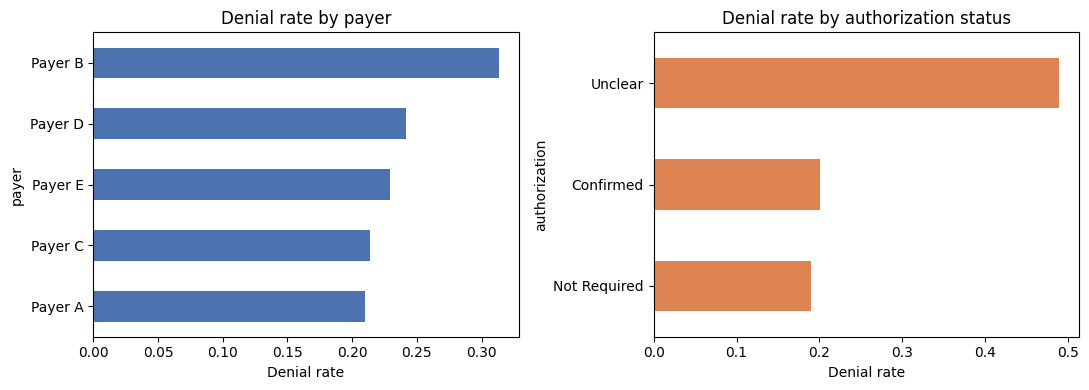

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df.groupby("payer")["denied"].mean().sort_values().plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("Denial rate by payer")
axes[0].set_xlabel("Denial rate")

df.groupby("authorization")["denied"].mean().sort_values().plot(kind="barh", ax=axes[1], color="#DD8452")
axes[1].set_title("Denial rate by authorization status")
axes[1].set_xlabel("Denial rate")

plt.tight_layout()
plt.show()

## 3. Feature engineering

Raw categories like `payer = "Payer B"` aren't very useful to a model on their own.
Following the article's approach, we convert them into **historical rate features**:

- Payer denial rate
- CPT denial rate
- Payer + CPT combined denial rate
- Provider historical denial rate

**Important (data leakage):** these historical rates must be computed from the
**training set only**, then mapped onto the test set. If we compute them from the
full dataset first, the test claims "leak" information about their own outcome into
their own features, and the evaluation numbers below would look better than the
model would actually perform on genuinely new claims.

In [ ]:
feature_cols = ["payer", "cpt", "specialty", "pos", "provider", "modifier",
                "authorization", "billed_amount", "days_to_submission", "prior_similar_denied"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df[feature_cols + ["claim_id"]], df["denied"],
    test_size=0.25, random_state=RANDOM_STATE, stratify=df["denied"]
)

train = X_train_raw.copy()
train["denied"] = y_train.values
GLOBAL_RATE = y_train.mean()

def rate_map(train_df, group_cols, min_count=15):
    """Historical denial rate per group, computed on TRAIN only, with a
    minimum sample size fallback to the global rate to avoid noisy small groups."""
    g = train_df.groupby(group_cols)["denied"].agg(["mean", "count"])
    g.loc[g["count"] < min_count, "mean"] = GLOBAL_RATE
    return g["mean"].to_dict()

payer_rate = rate_map(train, "payer")
cpt_rate = rate_map(train, "cpt")
payer_cpt_rate = rate_map(train, ["payer", "cpt"], min_count=8)
provider_rate = rate_map(train, "provider", min_count=20)

def add_engineered_features(frame):
    frame = frame.copy()
    frame["payer_denial_rate"] = frame["payer"].map(payer_rate).fillna(GLOBAL_RATE)
    frame["cpt_denial_rate"] = frame["cpt"].map(cpt_rate).fillna(GLOBAL_RATE)
    frame["payer_cpt_denial_rate"] = frame.apply(
        lambda r: payer_cpt_rate.get((r["payer"], r["cpt"]), GLOBAL_RATE), axis=1
    )
    frame["provider_denial_rate"] = frame["provider"].map(provider_rate).fillna(GLOBAL_RATE)
    return frame

X_train = add_engineered_features(X_train_raw)
X_test = add_engineered_features(X_test_raw)

engineered_num_cols = ["billed_amount", "days_to_submission", "prior_similar_denied",
                        "payer_denial_rate", "cpt_denial_rate", "payer_cpt_denial_rate",
                        "provider_denial_rate"]
categorical_cols = ["specialty", "pos", "modifier", "authorization"]

X_train[engineered_num_cols + categorical_cols].head()

,billed_amount,days_to_submission,prior_similar_denied,payer_denial_rate,cpt_denial_rate,payer_cpt_denial_rate,provider_denial_rate,specialty,pos,modifier,authorization
1405,63.16,8,1,0.325581,0.273050,0.333333,0.151261,Radiology,Office,None,Not Required
169,371.99,5,0,0.212389,0.215213,0.155963,0.236364,Physical Therapy,Inpatient,None,Not Required
240,377.66,13,0,0.206974,0.244482,0.217054,0.263636,Internal Medicine,Inpatient,None,Confirmed
3261,195.87,4,0,0.250000,0.273050,0.272000,0.247312,Physical Therapy,Inpatient,25,Not Required
131,277.49,21,0,0.209821,0.244482,0.203704,0.186916,Internal Medicine,Outpatient,25,Confirmed


## 4. Build the preprocessing + model pipelines

We one-hot encode the small categorical fields and pass the engineered rate features
through as-is. Three models, from simple/interpretable to more powerful:

- **Logistic Regression** — the article's "strong, interpretable baseline"
- **Random Forest** — captures non-linear interactions
- **XGBoost** — the gradient-boosting workhorse for tabular data

In [ ]:
preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
], remainder="passthrough")

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=8, class_weight="balanced_subsample", random_state=RANDOM_STATE
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        eval_metric="logloss", random_state=RANDOM_STATE,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
    ),
}

pipelines = {}
X_train_model = X_train[categorical_cols + engineered_num_cols]
X_test_model = X_test[categorical_cols + engineered_num_cols]

for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train_model, y_train)
    pipelines[name] = pipe

print("Models trained:", list(pipelines.keys()))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Models trained: ['Logistic Regression', 'Random Forest', 'XGBoost']


## 5. Evaluate — the metrics that actually matter

As the article points out, **accuracy is misleading** on an imbalanced problem like
this (roughly 75% of claims are *not* denied). A model that just predicts "not
denied" every time could still look "accurate" while being useless.

Instead we look at:
- **Recall** for the denied class — are we catching the claims that actually get denied?
- **Precision** — when we flag a claim as high-risk, how often are we right? (too many false alarms burns out the AR team)
- **ROC-AUC** and **PR-AUC** — overall ranking quality across all thresholds

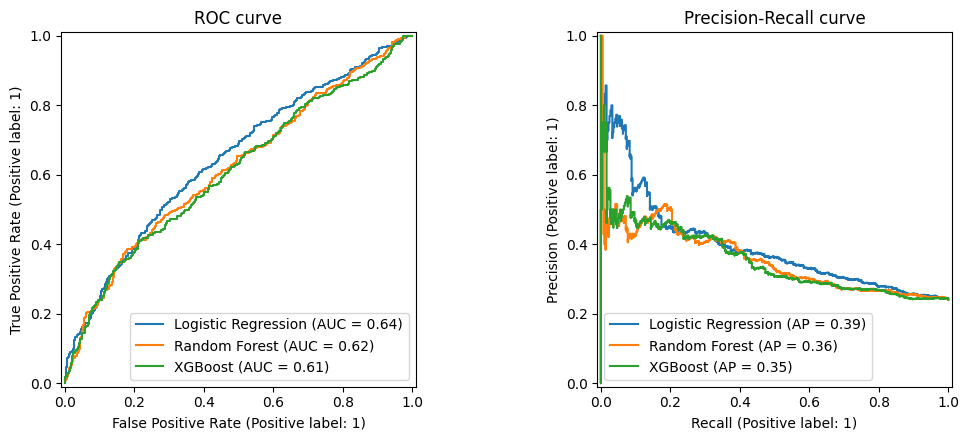

,ROC-AUC,PR-AUC,Precision (denied),Recall (denied),F1 (denied)
Model,,,,,
Logistic Regression,0.645,0.394,0.363,0.499,0.420
Random Forest,0.618,0.355,0.407,0.371,0.388
XGBoost,0.608,0.353,0.338,0.435,0.381


In [ ]:
results = []
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for name, pipe in pipelines.items():
    y_prob = pipe.predict_proba(X_test_model)[:, 1]
    y_pred = pipe.predict(X_test_model)

    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        "Model": name,
        "ROC-AUC": round(roc_auc, 3),
        "PR-AUC": round(pr_auc, 3),
        "Precision (denied)": round(report["1"]["precision"], 3),
        "Recall (denied)": round(report["1"]["recall"], 3),
        "F1 (denied)": round(report["1"]["f1-score"], 3),
    })

    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, y_prob, name=name, ax=axes[1])

axes[0].set_title("ROC curve")
axes[1].set_title("Precision-Recall curve")
plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results).set_index("Model")
results_df

Best model by ROC-AUC: Logistic Regression


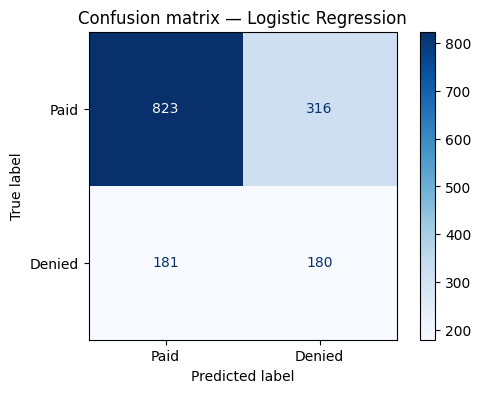

In [ ]:
# Confusion matrix for the best model by ROC-AUC
best_model_name = results_df["ROC-AUC"].idxmax()
best_pipe = pipelines[best_model_name]
y_pred_best = best_pipe.predict(X_test_model)

print(f"Best model by ROC-AUC: {best_model_name}")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, display_labels=["Paid", "Denied"], cmap="Blues")
plt.title(f"Confusion matrix — {best_model_name}")
plt.show()

## 6. What's driving denial risk? (feature importance)

This is the interpretability piece — useful for explaining *why* the model flagged
a claim, not just that it did.

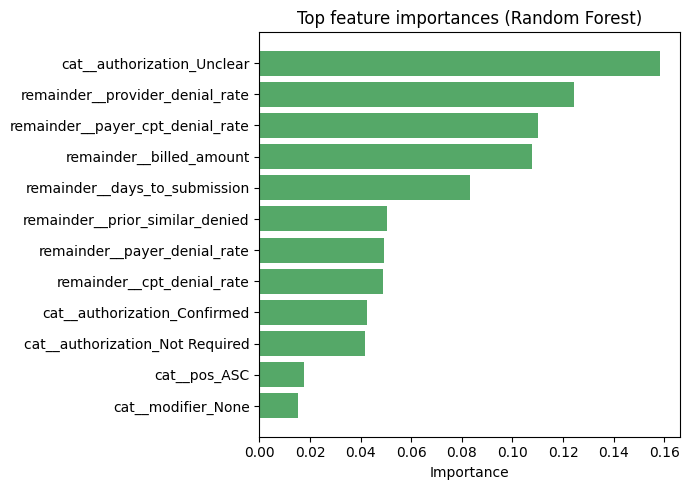

In [ ]:
rf_pipe = pipelines["Random Forest"]
feature_names = rf_pipe.named_steps["prep"].get_feature_names_out()
importances = rf_pipe.named_steps["model"].feature_importances_

imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=True).tail(12)

plt.figure(figsize=(7, 5))
plt.barh(imp_df["feature"], imp_df["importance"], color="#55A868")
plt.title("Top feature importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 7. From prediction to a risk-sorted worklist

This is the "predictive to prescriptive" step from the article: instead of working
claims first-in-first-out, sort them by predicted denial risk so the highest-risk
claims get reviewed **before** submission.

In [ ]:
scored = X_test_raw.copy()
scored["actual_denied"] = y_test.values
scored["predicted_risk"] = best_pipe.predict_proba(X_test_model)[:, 1]

worklist = scored.sort_values("predicted_risk", ascending=False).head(10)
worklist[["claim_id", "payer", "cpt", "authorization", "days_to_submission",
          "predicted_risk", "actual_denied"]].reset_index(drop=True)

,claim_id,payer,cpt,authorization,days_to_submission,predicted_risk,actual_denied
0,CLM002611,Payer B,80053,Unclear,1,0.912598,1
1,CLM005657,Payer E,80053,Unclear,12,0.911048,0
2,CLM002156,Payer E,20610,Unclear,15,0.907414,1
3,CLM003672,Payer B,36415,Unclear,15,0.906094,1
4,CLM001372,Payer E,36415,Unclear,2,0.900523,1
5,CLM004540,Payer D,99213,Unclear,4,0.890567,1
6,CLM002761,Payer A,99214,Unclear,9,0.886971,1
7,CLM004501,Payer B,20610,Unclear,16,0.886027,0
8,CLM002763,Payer B,97110,Unclear,4,0.883689,0
9,CLM001856,Payer A,71046,Unclear,9,0.881498,1


In [ ]:
def explain_claim(row):
    reasons = []
    if row["authorization"] == "Unclear":
        reasons.append("Authorization status unclear")
    if row["days_to_submission"] > 30:
        reasons.append("Long submission delay (>30 days)")
    elif row["days_to_submission"] > 15:
        reasons.append("Moderate submission delay (>15 days)")
    if row["prior_similar_denied"] == 1:
        reasons.append("Similar claim previously denied")
    if X_test.loc[row.name, "payer_denial_rate"] > GLOBAL_RATE * 1.3:
        reasons.append("Payer has an above-average denial rate")
    if X_test.loc[row.name, "provider_denial_rate"] > GLOBAL_RATE * 1.3:
        reasons.append("Provider has an above-average denial rate")
    return "; ".join(reasons) if reasons else "No single dominant factor — general risk profile"

top_claim = worklist.iloc[0]
print(f"Claim: {top_claim['claim_id']}")
print(f"Predicted denial risk: {top_claim['predicted_risk']:.0%}")
print(f"Contributing factors: {explain_claim(top_claim)}")
print(f"Suggested action: Verify authorization and filing requirements before submission.")

Claim: CLM002611
Predicted denial risk: 91%
Contributing factors: Authorization status unclear; Similar claim previously denied; Payer has an above-average denial rate
Suggested action: Verify authorization and filing requirements before submission.


## 8. Bonus: anomaly detection — catching a denial-rate spike

Not every problem shows up as a single risky claim. Sometimes a *provider's* overall
denial rate suddenly jumps — a payer policy changed, an EDI mapping broke, a new CPT
code is being coded incorrectly. Isolation Forest can flag providers whose recent
claim pattern looks statistically unusual compared to the rest.

Here we simulate a provider whose denial rate spikes in the most recent batch of
claims, and check whether anomaly detection picks it out.

In [ ]:
# Build a per-provider-per-week denial rate table, then inject one artificial spike
weeks = 12
provider_week_rows = []
for p in providers:
    base_rate = 1 - provider_skill_map[p]
    for w in range(weeks):
        n_claims = rng.integers(15, 40)
        denial_rate = np.clip(rng.normal(base_rate * 0.4, 0.03), 0, 1)
        provider_week_rows.append({"provider": p, "week": w, "denial_rate": denial_rate, "n_claims": n_claims})

pw_df = pd.DataFrame(provider_week_rows)

# Inject a spike: provider PR100's denial rate triples in week 11
spike_mask = (pw_df["provider"] == "PR100") & (pw_df["week"] == weeks - 1)
pw_df.loc[spike_mask, "denial_rate"] = pw_df.loc[spike_mask, "denial_rate"] * 3 + 0.15

iso = IsolationForest(contamination=0.03, random_state=RANDOM_STATE)
pw_df["anomaly_score"] = iso.fit_predict(pw_df[["denial_rate", "n_claims"]])
flagged = pw_df[pw_df["anomaly_score"] == -1].sort_values("denial_rate", ascending=False)

print("Flagged provider-weeks (potential denial-rate anomalies):")
flagged[["provider", "week", "denial_rate", "n_claims"]]

Flagged provider-weeks (potential denial-rate anomalies):


,provider,week,denial_rate,n_claims
11,PR100,11,0.687174,35
406,PR133,10,0.259725,39
125,PR110,5,0.253110,18
405,PR133,9,0.249724,29
315,PR126,3,0.249268,38
314,PR126,2,0.245125,21
312,PR126,0,0.241700,34
436,PR136,4,0.241100,39
456,PR138,0,0.240741,21
316,PR126,4,0.227675,17


## 9. Wrap-up

What this notebook demonstrated, mapped back to the article's framing:

| Article concept | This notebook |
|---|---|
| Descriptive analytics | Section 2 (denial rate by payer/authorization) |
| Feature engineering | Section 3 (payer/CPT/provider historical rates) |
| Predictive analytics | Sections 4–6 (LogReg, RF, XGBoost + evaluation) |
| Prescriptive analytics | Section 7 (risk-sorted worklist + suggested action) |
| Anomaly detection | Section 8 (Isolation Forest on provider denial rates) |
| Human-in-the-loop | The model outputs a **risk score + reasons** — a person still decides what to do |

**Ideas to extend this as a real project:**
- Swap the synthetic generator for de-identified real claims data (with proper HIPAA/privacy handling)
- Add SHAP values instead of plain feature importance, for per-claim explanations
- Track prediction → intervention → outcome over time (the feedback loop from the article) and monitor for model drift
- Turn Section 7 into a small dashboard (e.g. Streamlit) that AR staff could actually use as a daily worklist
